# 🧩 Structured Output Enforcer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/structured-extractor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/structured-extractor/demo.ipynb)

**Stop your pipeline from crashing when the LLM returns *almost*-JSON.**

You ask an LLM for JSON and get back a markdown code fence, a chatty preamble, a trailing comma, Python's `True`/`None`, string-wrapped numbers, or a missing field. Plain `json.loads()` throws and everything downstream dies.

This notebook builds a deterministic **extract → repair → coerce → validate** pipeline that turns messy model text into a validated object - and reports *exactly what it fixed*.

**What we cover**
1. The problem: why `json.loads()` isn't enough
2. Step 1 - extract JSON from noisy text
3. Step 2 - repair common malformations
4. Step 3 - coerce values to declared types
5. Step 4 - validate against a schema
6. Batch results + a chart: naive vs. enforced
7. Try your own

## 1. The problem

Here are eight realistically-messy "model outputs" for a ticket-triage task. We asked for JSON with `category`, `priority`, `urgent`, `sentiment_score`, `tags`. Watch how many survive a plain `json.loads()`.

In [1]:
from __future__ import annotations
import json, re
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

SAMPLE_OUTPUTS = [
    ("clean", '{"category": "billing", "priority": 2, "urgent": false, "sentiment_score": -0.4, "tags": ["refund", "invoice"]}'),
    ("code fence", '```json\n{"category": "login", "priority": 1, "urgent": true, "sentiment_score": -0.8, "tags": ["auth", "outage"]}\n```'),
    ("chatty preamble", 'Sure! Here is the structured result:\n{"category": "feature", "priority": 3, "urgent": false, "sentiment_score": 0.2, "tags": ["request"]}\nLet me know if you need more.'),
    ("trailing comma", '{"category": "bug", "priority": 2, "urgent": true, "sentiment_score": -0.5, "tags": ["crash",],}'),
    ("python literals", "{'category': 'billing', 'priority': 2, 'urgent': True, 'sentiment_score': -0.3, 'tags': ['charge']}"),
    ("string numbers", '{"category": "shipping", "priority": "1", "urgent": "yes", "sentiment_score": "-0.6", "tags": ["delay"]}'),
    ("missing field", '{"category": "general", "urgent": false, "sentiment_score": 0.1, "tags": []}'),
    ("not json", "I could not determine the category for this ticket."),
]

def naive_parses(raw):
    try:
        return isinstance(json.loads(raw.strip()), dict)
    except Exception:
        return False

for label, raw in SAMPLE_OUTPUTS:
    print(f"{'OK  ' if naive_parses(raw) else 'FAIL'}  {label}")
print(f"\nNaive json.loads: {sum(naive_parses(r) for _,r in SAMPLE_OUTPUTS)}/{len(SAMPLE_OUTPUTS)}")

OK    clean
FAIL  code fence
FAIL  chatty preamble
FAIL  trailing comma
FAIL  python literals
OK    string numbers
OK    missing field
FAIL  not json

Naive json.loads: 3/8


Only 3 of 8 parse. The other 5 aren't *wrong answers* - the model got the content right, it just wrapped or formatted it in a way `json.loads()` rejects. Let's recover them.

## 2. Step 1 - extract JSON from noisy text

Strip markdown fences, then walk to the first **balanced** `{...}` so any prose before or after is dropped.

In [2]:
_FENCE_RE = re.compile(r"```(?:json)?\s*(.*?)```", re.DOTALL | re.IGNORECASE)

def extract_json_block(raw: str) -> Tuple[str, List[str]]:
    repairs: List[str] = []
    text = raw.strip()
    fence = _FENCE_RE.search(text)
    if fence:
        text = fence.group(1).strip()
        repairs.append("stripped markdown code fence")
    start = text.find("{")
    if start == -1:
        return text, repairs
    depth = 0; end = -1; in_str = False; escape = False
    for i in range(start, len(text)):
        ch = text[i]
        if escape: escape = False; continue
        if ch == "\\": escape = True; continue
        if ch == '"': in_str = not in_str
        elif not in_str:
            if ch == "{": depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0: end = i; break
    if end != -1 and (start > 0 or end < len(text) - 1):
        text = text[start:end+1]; repairs.append("removed surrounding prose")
    elif start > 0:
        text = text[start:]; repairs.append("removed leading prose")
    return text, repairs

demo = 'Sure! Here is the result:\n{"category": "feature", "priority": 3}\nHope that helps!'
out, reps = extract_json_block(demo)
print("extracted:", out)
print("repairs:  ", reps)

extracted: {"category": "feature", "priority": 3}
repairs:   ['removed surrounding prose']


## 3. Step 2 - repair common malformations

Trailing commas, Python `True/False/None`, single quotes, unquoted keys. All deterministic regex fixes.

In [3]:
_TRAILING_COMMA_RE = re.compile(r",\s*([}\]])")
_UNQUOTED_KEY_RE = re.compile(r"([{,]\s*)([A-Za-z_][A-Za-z0-9_]*)(\s*:)")
_PY_LITERALS = [("True", "true"), ("False", "false"), ("None", "null")]

def repair_json_text(text: str) -> Tuple[str, List[str]]:
    repairs: List[str] = []
    if _TRAILING_COMMA_RE.search(text):
        text = _TRAILING_COMMA_RE.sub(r"\1", text); repairs.append("removed trailing comma")
    for py, js in _PY_LITERALS:
        pat = re.compile(rf"(?<![\"\w]){py}(?![\"\w])")
        if pat.search(text):
            text = pat.sub(js, text); repairs.append(f"converted Python {py} -> {js}")
    if "'" in text and '"' not in text:
        text = text.replace("'", '"'); repairs.append("converted single quotes to double quotes")
    if _UNQUOTED_KEY_RE.search(text):
        text = _UNQUOTED_KEY_RE.sub(r'\1"\2"\3', text); repairs.append("quoted unquoted keys")
    return text, repairs

broken = "{'category': 'bug', 'urgent': True, 'tags': ['crash',],}"
fixed, reps = repair_json_text(broken)
print("before:", broken)
print("after: ", fixed)
print("repairs:", reps)
print("parses now?", bool(json.loads(fixed)))

before: {'category': 'bug', 'urgent': True, 'tags': ['crash',],}
after:  {"category": "bug", "urgent": true, "tags": ["crash"]}
repairs: ['removed trailing comma', 'converted Python True -> true', 'converted single quotes to double quotes']
parses now? True


## 4. Step 3 - coerce values to declared types

Models love returning `"1"` for an int or `"yes"` for a bool. We cast to the type the schema declares.

In [4]:
_TYPES = {"str": str, "int": int, "float": float, "bool": bool, "list": list}

def coerce_value(value: Any, target: str) -> Tuple[Any, bool]:
    py_type = _TYPES.get(target)
    if py_type is None or (isinstance(value, py_type) and not (target in ("int","float") and isinstance(value, bool))):
        return value, False
    try:
        if target == "int":   return int(float(str(value).strip())), True
        if target == "float": return float(str(value).strip()), True
        if target == "bool":
            s = str(value).strip().lower()
            if s in ("true","yes","1"):  return True, True
            if s in ("false","no","0"):  return False, True
            return value, False
        if target == "str":  return str(value), True
        if target == "list" and isinstance(value, str):
            return [v.strip() for v in value.split(",") if v.strip()], True
    except (ValueError, TypeError):
        return value, False
    return value, False

for v, t in [("1","int"), ("yes","bool"), ("-0.6","float"), (2,"int")]:
    print(f"{v!r:>8} as {t:<5} -> {coerce_value(v, t)}")

     '1' as int   -> (1, True)
   'yes' as bool  -> (True, True)
  '-0.6' as float -> (-0.6, True)
       2 as int   -> (2, False)


## 5. Step 4 - validate against a schema

Put it together: extract → parse (repair on failure) → coerce declared fields → check required presence + final types.

In [5]:
@dataclass
class Field:
    name: str; type: str = "str"; required: bool = True

@dataclass
class Schema:
    fields: List[Field]

@dataclass
class Result:
    ok: bool; data: Optional[Dict[str, Any]]
    repairs: List[str] = field(default_factory=list)
    errors: List[str] = field(default_factory=list)
    @property
    def repaired(self): return self.ok and len(self.repairs) > 0

def enforce(raw: str, schema: Schema) -> Result:
    repairs: List[str] = []; errors: List[str] = []
    candidate, r1 = extract_json_block(raw); repairs += r1
    try:
        data = json.loads(candidate)
    except json.JSONDecodeError:
        candidate, r2 = repair_json_text(candidate); repairs += r2
        try:
            data = json.loads(candidate)
        except json.JSONDecodeError as exc:
            return Result(False, None, repairs, [f"unparseable JSON: {exc.msg}"])
    if not isinstance(data, dict):
        return Result(False, None, repairs, [f"expected object, got {type(data).__name__}"])
    for f in schema.fields:
        if f.name in data:
            nv, changed = coerce_value(data[f.name], f.type)
            if changed: data[f.name] = nv; repairs.append(f"coerced '{f.name}' to {f.type}")
    for f in schema.fields:
        if f.name not in data:
            if f.required: errors.append(f"missing required field '{f.name}'")
            continue
        pt = _TYPES.get(f.type); val = data[f.name]
        bad_bool = f.type in ("int","float") and isinstance(val, bool)
        if pt and (not isinstance(val, pt) or bad_bool):
            errors.append(f"field '{f.name}' should be {f.type}, got {type(val).__name__}")
    return Result(not errors, data, repairs, errors)

TICKET_SCHEMA = Schema([
    Field("category","str"), Field("priority","int"), Field("urgent","bool"),
    Field("sentiment_score","float"), Field("tags","list"),
])

r = enforce(SAMPLE_OUTPUTS[5][1], TICKET_SCHEMA)  # "string numbers"
print("valid:  ", r.ok)
print("data:   ", r.data)
print("repairs:", r.repairs)

valid:   True
data:    {'category': 'shipping', 'priority': 1, 'urgent': True, 'sentiment_score': -0.6, 'tags': ['delay']}
repairs: ["coerced 'priority' to int", "coerced 'urgent' to bool", "coerced 'sentiment_score' to float"]


## 6. Batch results: naive vs. enforced

Run every sample through both paths and tabulate.

In [6]:
import pandas as pd
rows = []
for label, raw in SAMPLE_OUTPUTS:
    res = enforce(raw, TICKET_SCHEMA)
    rows.append({
        "case": label,
        "naive_ok": naive_parses(raw),
        "enforced_ok": res.ok,
        "n_repairs": len(res.repairs),
        "repairs": "; ".join(res.repairs) or "-",
        "errors": "; ".join(res.errors) or "-",
    })
df = pd.DataFrame(rows)
df

,case,naive_ok,enforced_ok,n_repairs,repairs,errors
0,clean,True,True,0,-,-
1,code fence,False,True,1,stripped markdown code fence,-
2,chatty preamble,False,True,1,removed surrounding prose,-
3,trailing comma,False,True,1,removed trailing comma,-
4,python literals,False,True,2,converted Python True -> true; converted singl...,-
5,string numbers,True,True,3,coerced 'priority' to int; coerced 'urgent' to...,-
6,missing field,True,False,0,-,missing required field 'priority'
7,not json,False,False,0,-,unparseable JSON: Expecting value


### Chart: how many outputs each path saves

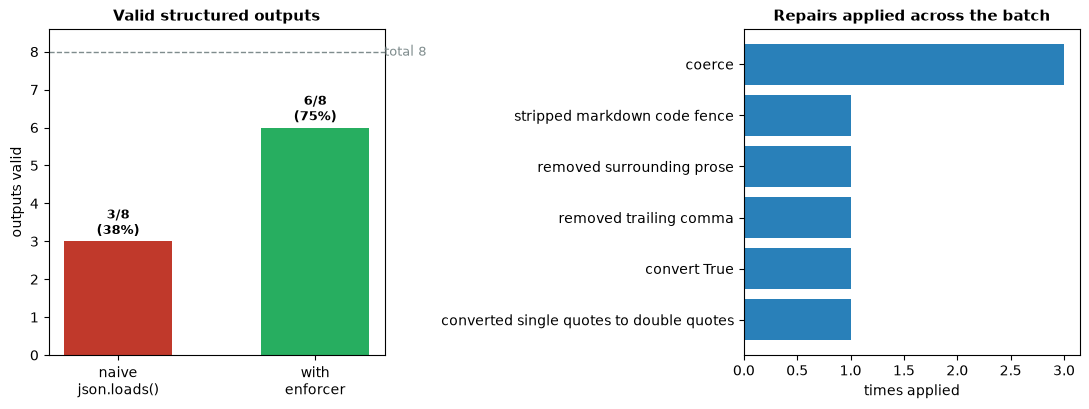

Recovered 3 outputs that json.loads() would have crashed on.


In [7]:
import matplotlib.pyplot as plt

naive = int(df["naive_ok"].sum())
enforced = int(df["enforced_ok"].sum())
total = len(df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: valid counts
bars = ax1.bar(["naive\njson.loads()", "with\nenforcer"], [naive, enforced],
               color=["#c0392b", "#27ae60"], width=0.55)
ax1.axhline(total, ls="--", lw=1, color="#7f8c8d")
ax1.text(1.35, total, f"total {total}", va="center", color="#7f8c8d", fontsize=9)
ax1.set_ylabel("outputs valid"); ax1.set_ylim(0, total + 0.6)
ax1.set_title("Valid structured outputs", fontsize=11, weight="bold")
for b, v in zip(bars, [naive, enforced]):
    ax1.text(b.get_x()+b.get_width()/2, v+0.08, f"{v}/{total}\n({round(100*v/total)}%)",
             ha="center", va="bottom", fontsize=9, weight="bold")

# Right: which repair fired how often
from collections import Counter
c = Counter()
for _, raw in SAMPLE_OUTPUTS:
    for rep in enforce(raw, TICKET_SCHEMA).repairs:
        key = rep.split(" -> ")[0].replace("converted Python ", "convert ")
        key = key.replace("coerced ", "coerce ").split(" '")[0] if key.startswith("coerced") else key
        c[key] += 1
items = c.most_common()
ax2.barh([k for k,_ in items][::-1], [v for _,v in items][::-1], color="#2980b9")
ax2.set_xlabel("times applied"); ax2.set_title("Repairs applied across the batch", fontsize=11, weight="bold")

plt.tight_layout()
plt.savefig("repair_breakdown.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Recovered {enforced - naive} outputs that json.loads() would have crashed on.")

## 7. Summary

| | naive `json.loads()` | with enforcer |
|---|---|---|
| valid outputs | 3 / 8 (38%) | 6 / 8 (75%) |

The two remaining failures are **correct** failures - one output is missing a required field, the other isn't JSON at all. That's the point: repair the fixable, and flag the genuinely-broken for a model retry instead of silently passing bad data downstream.

## Try your own

Paste a real LLM response and declare the fields you expected.

In [8]:
# --- Edit these two lines ---
my_output = """```json
{"name": "Ada Lovelace", "born": "1815", "is_mathematician": True,}
```"""

my_schema = Schema([
    Field("name", "str"),
    Field("born", "int"),
    Field("is_mathematician", "bool"),
])

res = enforce(my_output, my_schema)
print("valid:  ", res.ok, "(repaired)" if res.repaired else "")
print("data:   ", res.data)
print("repairs:", res.repairs)
print("errors: ", res.errors or "none")

valid:   True (repaired)
data:    {'name': 'Ada Lovelace', 'born': 1815, 'is_mathematician': True}
repairs: ['stripped markdown code fence', 'removed trailing comma', 'converted Python True -> true', "coerced 'born' to int"]
errors:  none


---

**Part of [Phoebe's FDE build sprint](https://github.com/phoebefu6/phoebe-the-builder)** - Day 87, LLMOps & GenAI Platform.

For the interactive Streamlit version (paste any response, edit the schema live):
```bash
pip install -r requirements.txt
streamlit run app.py
```